In [7]:
import os
os.chdir('/content/drive/MyDrive/Colab Notebooks')

In [8]:
# импорт модулей
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import sklearn

In [9]:
# загрузка датасета
from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
# создание своего разбиения датасета
from sklearn.model_selection import train_test_split
# объединяем в один набор
X = np.concatenate((X_train, X_test))
y = np.concatenate((y_train, y_test))
# разбиваем по вариантам
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 10000,
                                                    train_size = 60000,
                                                    random_state = 124)

Shape of X train: (60000, 28, 28)
Shape of y train: (60000,)


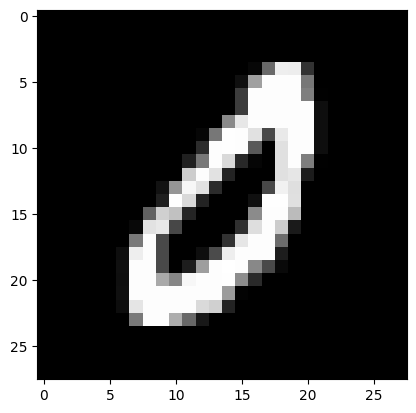

0


In [11]:
# вывод размерностей
print('Shape of X train:', X_train.shape)
print('Shape of y train:', y_train.shape)
# вывод изображения
plt.imshow(X_train[123], cmap=plt.get_cmap('gray'))
plt.show()
# вывод метки для этого изображения
print(y_train[123])

In [12]:
# развернем каждое изображение 28*28 в вектор 784
num_pixels = X_train.shape[1] * X_train.shape[2]
X_train = X_train.reshape(X_train.shape[0], num_pixels) / 255
X_test = X_test.reshape(X_test.shape[0], num_pixels) / 255
print('Shape of transformed X train:', X_train.shape)

Shape of transformed X train: (60000, 784)


In [13]:
# переведем метки в one-hot
from keras.utils import to_categorical
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
print('Shape of transformed y train:', y_train.shape)
num_classes = y_train.shape[1]

Shape of transformed y train: (60000, 10)


In [14]:
from keras.models import Sequential
from keras.layers import Dense
model = Sequential()
model.add(Dense(units=300, input_dim=num_pixels, activation='sigmoid'))
model.add(Dense(units=100, activation='sigmoid'))
model.add(Dense(units=num_classes, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
print(model.summary())


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

None


In [16]:
H = model.fit(X_train, y_train, validation_split=0.1, epochs=100)

Epoch 1/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3744 - loss: 2.1622 - val_accuracy: 0.5870 - val_loss: 1.9509
Epoch 2/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6436 - loss: 1.5903 - val_accuracy: 0.7255 - val_loss: 1.2342
Epoch 3/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7743 - loss: 1.0031 - val_accuracy: 0.8128 - val_loss: 0.8268
Epoch 4/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8266 - loss: 0.7232 - val_accuracy: 0.8425 - val_loss: 0.6405
Epoch 5/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8498 - loss: 0.5865 - val_accuracy: 0.8635 - val_loss: 0.5407
Epoch 6/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8650 - loss: 0.5103 - val_accuracy: 0.8760 - val_loss: 0.4809
Epoch 7/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8748 - loss: 0.4618 - val_accuracy: 0.8838 - val_loss: 0.4412
Epoch 8/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8835 - loss: 

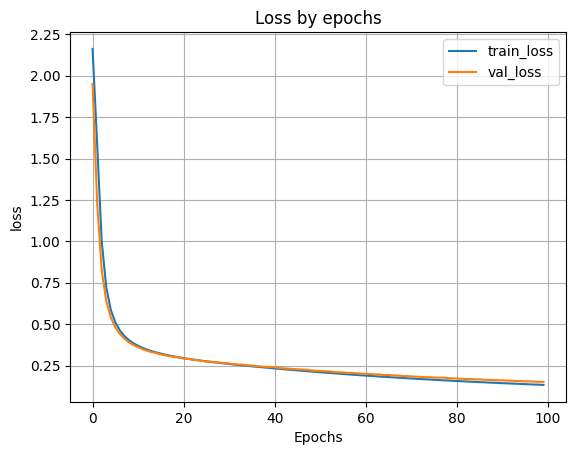

In [17]:
# вывод графика ошибки по эпохам
plt.plot(H.history['loss'])
plt.plot(H.history['val_loss'])
plt.grid()
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend(['train_loss', 'val_loss'])
plt.title('Loss by epochs')
plt.show()

In [18]:
scores = model.evaluate(X_test, y_test)
print('Loss on test data:', scores[0])
print('Accuracy on test data:', scores[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9569 - loss: 0.1532
Loss on test data: 0.1531580537557602
Accuracy on test data: 0.9569000005722046


In [19]:
# сохранение модели на диск, к примеру, в папку best_model
# В общем случае может быть указан произвольный путь
model.save('best_model.keras')

In [20]:
# Загрузка модели с диска
from keras.models import load_model
model = load_model('best_model.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
NN output: [[6.3809284e-07 9.8095554e-01 1.5845270e-03 2.3292715e-03 3.0219532e-04
  1.8970508e-04 3.4711073e-05 1.2225374e-02 2.1632083e-03 2.1476013e-04]]


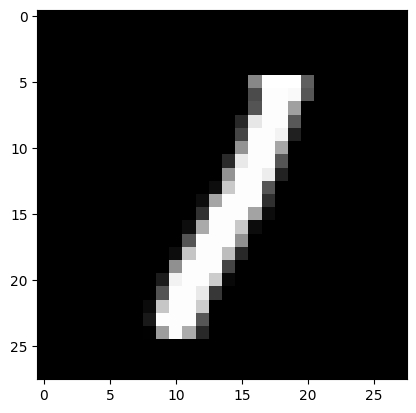

Real mark:  1
NN answer:  1


In [21]:
# вывод тестового изображения и результата распознавания
n = 290
result = model.predict(X_test[n:n+1])
print('NN output:', result)

plt.imshow(X_test[n].reshape(28,28), cmap=plt.get_cmap('gray'))
plt.show()
print('Real mark: ', str(np.argmax(y_test[n])))
print('NN answer: ', str(np.argmax(result)))

In [22]:
# загрузка собственного изображения
from PIL import Image
file_data = Image.open('penis).png')
file_data = file_data.convert('L')
# перевод в градации серого
test_img = np.array(file_data)

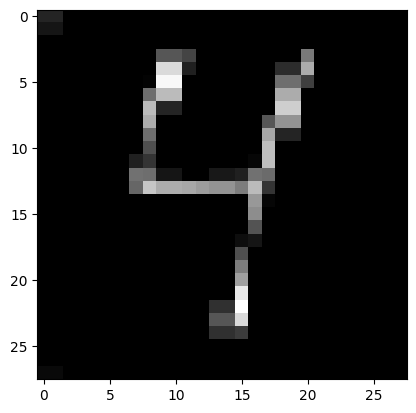

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
I think it's  5


In [23]:
# вывод собственного изображения
plt.imshow(test_img, cmap=plt.get_cmap('gray'))
plt.show()
# предобработка
test_img = test_img / 255
test_img = test_img.reshape(1, num_pixels)
# распознавание
result = model.predict(test_img)
print('I think it\'s ', np.argmax(result))

In [ ]:
model.save('best_model.keras')